# What Drives the Price of a Home?
### Capstone Initial Report and Exploratory Data Analysis (Module 20)
**Author:** Neda Nadjmabadi

This notebook works through the CRISP-DM stages on King County (Seattle-area) home sales to answer a
two-sided question: how much of a home's price comes from the **house itself** (size, quality, condition)
versus the **location and market demand** around it (distance to the city, ZIP code). The end product is a
cleaned dataset, exploratory visualizations, engineered features, and a **baseline regression model** that
Module 24 will build on.

## 1. Business Understanding

**Research question:** Which features of a home, and which qualities of its location, have the biggest
effect on its sale price, and how accurately can we predict what a house will sell for once we account for both?

**Why it matters:** The person this helps most is an owner of an older home deciding what to fix before
selling. Their real question is not *"should I renovate"* but *"renovate what, and in what order, given where
my house already sits in the market."* Separating the price that comes from the house from the price that
comes from the neighborhood tells a seller where a renovation budget actually pays back.

In [1]:
# ---- Libraries ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
RANDOM_STATE = 42

## 2. Data Understanding

Each row is one home sale in King County, WA (May 2014 to May 2015), with the home's physical attributes, its location (ZIP, latitude, longitude), and the final sale price.

In [2]:
df = pd.read_csv('../data/kc_house_data.csv')
print('Rows, columns:', df.shape)
df.head()

Rows, columns: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,"221,900.00",3,1.00,1180,5650,1.00,0,0,...,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,20141209T000000,"538,000.00",3,2.25,2570,7242,2.00,0,0,...,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,20150225T000000,"180,000.00",2,1.00,770,10000,1.00,0,0,...,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,20141209T000000,"604,000.00",4,3.00,1960,5000,1.00,0,0,...,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,20150218T000000,"510,000.00",3,2.00,1680,8080,1.00,0,0,...,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [3]:
# Structure and completeness
df.info()
print('\nTotal missing values:', int(df.isna().sum().sum()))
print('Duplicate ids:', int(df['id'].duplicated().sum()))

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [4]:
# Target summary
df['price'].describe()

count      21,613.00
mean      540,088.14
std       367,127.20
min        75,000.00
25%       321,950.00
50%       450,000.00
75%       645,000.00
max     7,700,000.00
Name: price, dtype: float64

## 3. Data Cleaning

The raw file has no nulls, but it needs a proper date type, de-duplication of homes that sold twice, and removal of a small number of impossible records (e.g., a known 33-bedroom data-entry error).

In [5]:
# Parse the sale date
df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')

# Some homes sold more than once in the window; keep the most recent sale per home
before = len(df)
df = df.drop_duplicates(subset='id', keep='last')

# Remove impossible / extreme-error rows
df = df[(df['bedrooms'] > 0) & (df['bedrooms'] <= 11)]
df = df[df['price'] > 0]

print(f'Removed {before - len(df):,} rows; clean dataset has {len(df):,} rows')

Removed 191 rows; clean dataset has 21,422 rows


## 4. Feature Engineering

Raw columns don't directly express the two ideas in the research question. These engineered features do:

- **`age_at_sale`** and **`was_renovated`** — how old the home was when sold, and whether it was updated.
- **`has_basement`** — a simple flag from basement square footage.
- **`dist_seattle`** — straight-line distance (miles) from each home to downtown Seattle, a clean proxy for
  *location demand / proximity to the city*.
- **`price_per_sqft`** — useful for EDA, not used as a model input (it leaks price).

In [6]:
# Haversine distance to downtown Seattle (location/demand proxy)
SEATTLE_LAT, SEATTLE_LON = 47.6062, -122.3321

def haversine_miles(lat, lon, lat0=SEATTLE_LAT, lon0=SEATTLE_LON):
    R = 3958.8  # Earth radius in miles
    dlat, dlon = np.radians(lat - lat0), np.radians(lon - lon0)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat0))*np.cos(np.radians(lat))*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df['sale_year']     = df['date'].dt.year
df['age_at_sale']   = (df['sale_year'] - df['yr_built']).clip(lower=0)
df['was_renovated'] = (df['yr_renovated'] > 0).astype(int)
df['has_basement']  = (df['sqft_basement'] > 0).astype(int)
df['dist_seattle']  = haversine_miles(df['lat'].values, df['long'].values)
df['price_per_sqft'] = df['price'] / df['sqft_living']

df[['age_at_sale','was_renovated','has_basement','dist_seattle','price_per_sqft']].describe()

,age_at_sale,was_renovated,has_basement,dist_seattle,price_per_sqft
count,"21,422.00","21,422.00","21,422.00","21,422.00","21,422.00"
mean,43.23,0.04,0.39,11.47,264.70
std,29.39,0.20,0.49,6.62,109.91
min,0.00,0.00,0.00,0.61,87.59
25%,17.00,0.00,0.00,6.07,182.93
50%,39.00,0.00,0.00,10.26,245.24
75%,63.00,0.00,1.00,15.70,318.68
max,115.00,1.00,1.00,47.90,810.14


## 5. Exploratory Data Analysis

### 5.1 The target is right-skewed

Prices run from tens of thousands to several million dollars. A log transform makes the distribution roughly symmetric, which is why the models below predict **log price**.

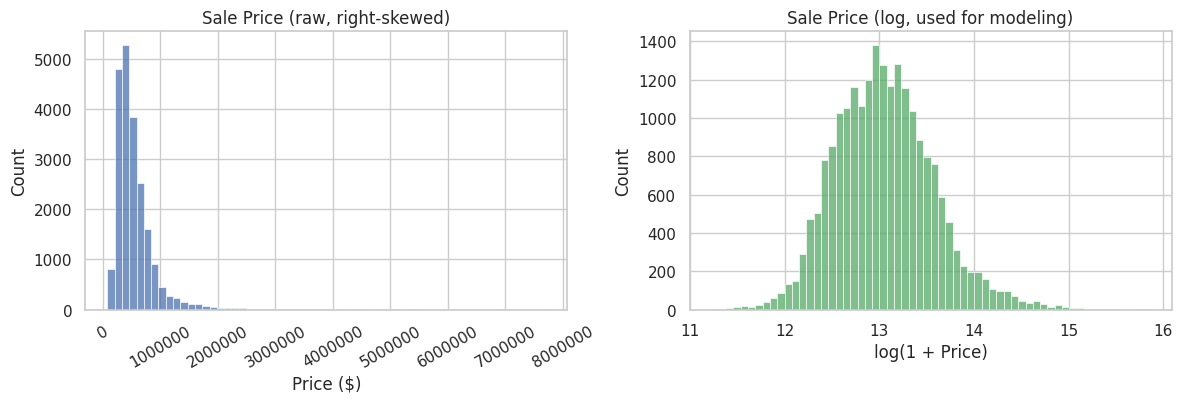

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sns.histplot(df['price'], bins=60, ax=ax[0], color='#4C72B0')
ax[0].set_title('Sale Price (raw, right-skewed)'); ax[0].set_xlabel('Price ($)')
ax[0].ticklabel_format(style='plain', axis='x'); ax[0].tick_params(axis='x', rotation=30)
sns.histplot(np.log1p(df['price']), bins=60, ax=ax[1], color='#55A868')
ax[1].set_title('Sale Price (log, used for modeling)'); ax[1].set_xlabel('log(1 + Price)')
plt.tight_layout(); plt.show()

### 5.2 What correlates with price?

Living area, construction grade, and bathrooms move most with price. Distance to Seattle is the strongest **negative** relationship, and it is the clearest single location signal in the data.

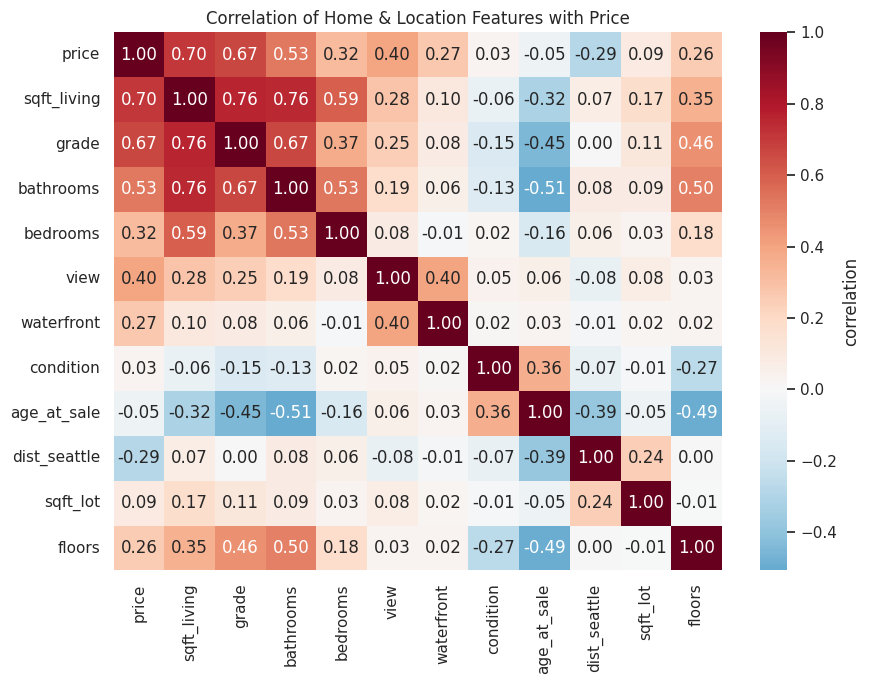

In [8]:
num_cols = ['price','sqft_living','grade','bathrooms','bedrooms','view','waterfront',
            'condition','age_at_sale','dist_seattle','sqft_lot','floors']
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, cbar_kws={'label': 'correlation'})
ax.set_title('Correlation of Home & Location Features with Price')
plt.tight_layout(); plt.show()

### 5.3 The house side: size and quality

Price rises with living area, and for any given size, higher-grade construction sits higher on the chart. Size and quality reinforce each other.

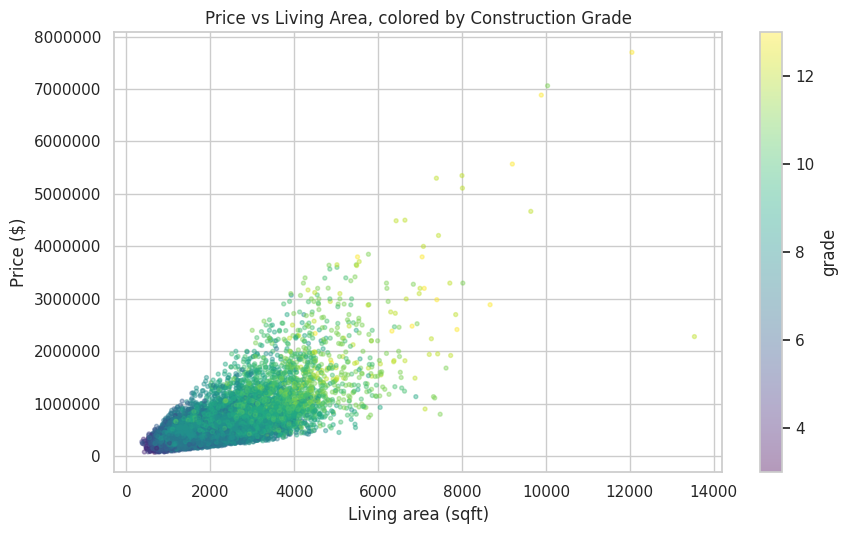

In [9]:
fig, ax = plt.subplots(figsize=(9, 5.5))
sc = ax.scatter(df['sqft_living'], df['price'], c=df['grade'], cmap='viridis', s=8, alpha=0.4)
ax.set_xlabel('Living area (sqft)'); ax.set_ylabel('Price ($)')
ax.set_title('Price vs Living Area, colored by Construction Grade')
ax.ticklabel_format(style='plain', axis='y'); plt.colorbar(sc, label='grade')
plt.tight_layout(); plt.show()

### 5.4 The location side: distance and ZIP code

Price falls steadily the farther a home is from downtown, and median prices differ about **8x** between the cheapest and priciest ZIP codes. Location is not a tie-breaker here; it is a primary driver.

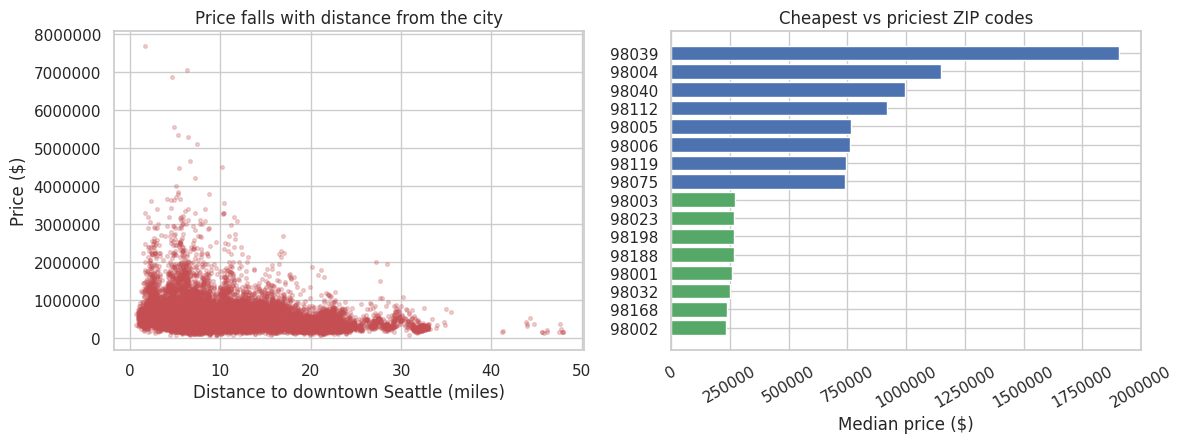

ZIP median price spread: $235,000 to $1,905,000  (8.1x)


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].scatter(df['dist_seattle'], df['price'], s=7, alpha=0.25, color='#C44E52')
ax[0].set_xlabel('Distance to downtown Seattle (miles)'); ax[0].set_ylabel('Price ($)')
ax[0].set_title('Price falls with distance from the city')
ax[0].ticklabel_format(style='plain', axis='y')

zip_med = df.groupby('zipcode')['price'].median().sort_values()
extremes = pd.concat([zip_med.head(8), zip_med.tail(8)])
bar_colors = ['#55A868']*8 + ['#4C72B0']*8
ax[1].barh([str(z) for z in extremes.index], extremes.values, color=bar_colors)
ax[1].set_xlabel('Median price ($)'); ax[1].set_title('Cheapest vs priciest ZIP codes')
ax[1].ticklabel_format(style='plain', axis='x'); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

spread = zip_med.max() / zip_med.min()
print(f'ZIP median price spread: ${zip_med.min():,.0f} to ${zip_med.max():,.0f}  ({spread:.1f}x)')

### 5.5 Where the money is on the map

Plotting every sale by latitude and longitude, colored by price, shows value concentrated around Seattle and the waterfront and thinning outward.

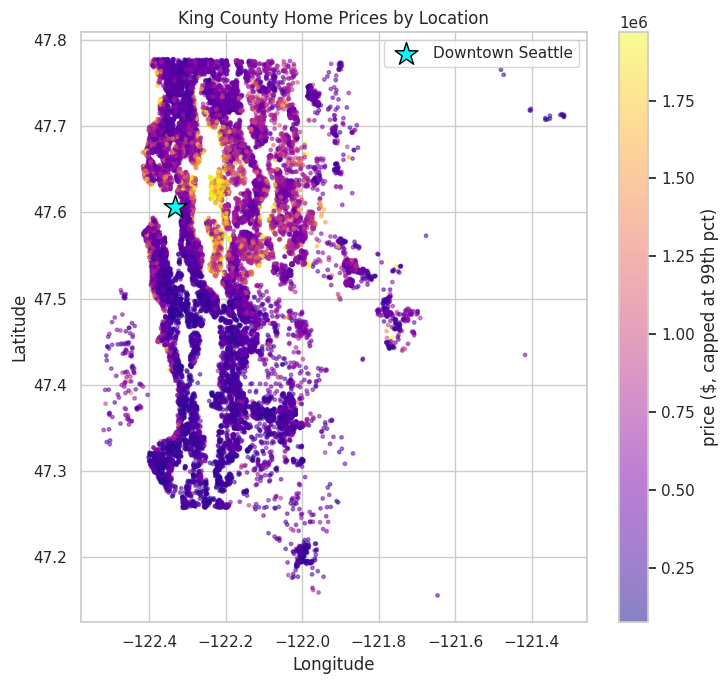

In [11]:
fig, ax = plt.subplots(figsize=(7.5, 7))
cap = df['price'].quantile(0.99)
sc = ax.scatter(df['long'], df['lat'], c=df['price'].clip(upper=cap), cmap='plasma', s=6, alpha=0.5)
ax.scatter(SEATTLE_LON, SEATTLE_LAT, marker='*', s=300, color='cyan',
           edgecolor='black', label='Downtown Seattle', zorder=5)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('King County Home Prices by Location'); ax.legend()
plt.colorbar(sc, label='price ($, capped at 99th pct)')
plt.tight_layout(); plt.show()

## 6. Baseline Modeling

**Setup.** The target is `log(1 + price)`, so errors read as roughly percentage errors and the skew is
controlled. Predictions are converted back to dollars for reporting. The feature set mixes house attributes
with the location signal `dist_seattle`. All models sit in a pipeline with `StandardScaler` so coefficients
are comparable and the regularized models are tuned fairly.

**Evaluation metric.** The headline metric is **RMSE in dollars**, because the audience thinks in dollars and
RMSE punishes the large misses that matter most on a big purchase. MAE and R² are reported alongside for context.

In [12]:
feature_cols = ['sqft_living','grade','bathrooms','bedrooms','sqft_lot','floors',
                'waterfront','view','condition','age_at_sale','was_renovated',
                'has_basement','sqft_living15','dist_seattle']

X = df[feature_cols].copy()
y = np.log1p(df['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]:,} rows   Test: {X_test.shape[0]:,} rows')

Train: 17,137 rows   Test: 4,285 rows


In [13]:
def evaluate(name, model):
    """Score a fitted model on the held-out test set, in dollars."""
    pred_log = model.predict(X_test)
    pred, true = np.expm1(pred_log), np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    r2   = r2_score(y_test, pred_log)
    print(f'{name:22s} RMSE=${rmse:,.0f}   MAE=${mae:,.0f}   R2(log)={r2:.3f}')
    return {'model': name, 'rmse': rmse, 'mae': mae, 'r2': r2}

# Naive reference: predict the training mean for everyone
naive = np.full(len(y_test), y_train.mean())
naive_rmse = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(naive)))
print(f'{"Naive (mean)":22s} RMSE=${naive_rmse:,.0f}')

Naive (mean)           RMSE=$391,243


In [14]:
results = []

# Baseline: ordinary linear regression
linear = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
linear.fit(X_train, y_train)
results.append(evaluate('Linear (baseline)', linear))

# Ridge with cross-validated alpha
ridge = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Ridge())]),
    {'model__alpha': [0.01, 0.1, 1, 10, 50]},
    cv=5, scoring='neg_root_mean_squared_error')
ridge.fit(X_train, y_train)
print('Ridge best alpha:', ridge.best_params_['model__alpha'])
results.append(evaluate('Ridge (CV)', ridge))

# Lasso with cross-validated alpha (also does feature selection)
lasso = GridSearchCV(
    Pipeline([('scaler', StandardScaler()), ('model', Lasso(max_iter=10000))]),
    {'model__alpha': [0.0001, 0.001, 0.01, 0.05]},
    cv=5, scoring='neg_root_mean_squared_error')
lasso.fit(X_train, y_train)
print('Lasso best alpha:', lasso.best_params_['model__alpha'])
results.append(evaluate('Lasso (CV)', lasso))

pd.DataFrame(results).set_index('model')

Linear (baseline)      RMSE=$184,632   MAE=$112,868   R2(log)=0.751


Ridge best alpha: 50
Ridge (CV)             RMSE=$184,308   MAE=$112,844   R2(log)=0.751


Lasso best alpha: 0.0001
Lasso (CV)             RMSE=$184,504   MAE=$112,855   R2(log)=0.751


,rmse,mae,r2
model,,,
Linear (baseline),"184,632.08","112,868.08",0.75
Ridge (CV),"184,308.21","112,844.24",0.75
Lasso (CV),"184,503.97","112,855.50",0.75


### 6.1 Which features carry the model?

Because inputs are standardized, the linear coefficients are directly comparable. Distance to Seattle, construction grade, and living area are the three largest by magnitude, confirming that a strong price model needs **both** the house and its location.

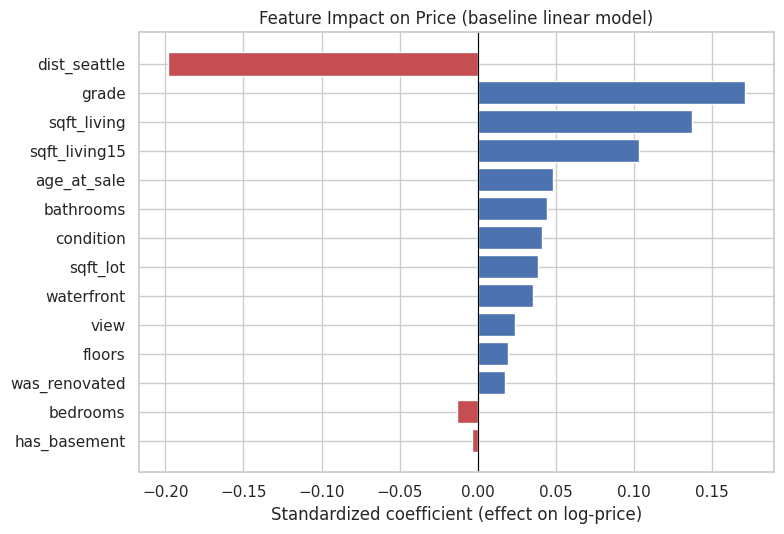

dist_seattle    -0.20
grade            0.17
sqft_living      0.14
sqft_living15    0.10
age_at_sale      0.05
bathrooms        0.04
condition        0.04
sqft_lot         0.04
waterfront       0.04
view             0.02
floors           0.02
was_renovated    0.02
bedrooms        -0.01
has_basement    -0.00
dtype: float64

In [15]:
coefs = pd.Series(linear.named_steps['model'].coef_, index=feature_cols)
coefs = coefs.sort_values(key=np.abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 5.5))
colors = ['#C44E52' if v < 0 else '#4C72B0' for v in coefs.values]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1])
ax.set_xlabel('Standardized coefficient (effect on log-price)')
ax.set_title('Feature Impact on Price (baseline linear model)')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout(); plt.show()
coefs.round(3)

## 7. Findings So Far (plain language)

- A simple, explainable model predicts sale price with a typical error around **\$185,000 RMSE** and a
  median-style error (MAE) near **\$113,000**, cutting the naive error of ~\$391,000 by more than half. It
  explains about **75%** of the variation in (log) price.
- **Location is a primary driver, not a footnote.** Distance to downtown Seattle is the single strongest
  standardized predictor, and median prices vary about **8x** across ZIP codes.
- **On the house side, size and construction grade dominate.** Bathrooms, view, and waterfront add real but
  smaller amounts; **bedroom count and having a basement add almost nothing** once size and grade are known.
- **Regularization (Ridge/Lasso) barely changed accuracy**, which tells us the baseline isn't overfit and the
  signal is carried by a handful of strong, mostly independent features rather than many weak ones.

**What this means for a seller:** much of a home's price is set by where it sits, which no renovation can
change. The features an owner *can* influence and that actually move price are those tied to usable space and
finish quality, not bedroom count or a finished basement on its own.

## 8. Next Steps (for Module 24)

- Add a **ZIP-level demand feature** (median price per ZIP, computed on training data only to avoid leakage) to
  capture neighborhood effects the single distance feature misses.
- Try **non-linear models** (Random Forest, Gradient Boosting) and compare them to this baseline on the same
  RMSE metric.
- Translate coefficients into a **plain "what pays back" ranking** for renovations, with dollar estimates.
- Test the model on a second market to check how well the approach transfers.